In [99]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets
from PIL import Image

In [294]:
N = 600000
k = 9
p = 0.9

W = np.random.binomial(1, p, N)
U = np.random.binomial(k, p, N)
T = np.random.binomial(1, (1+W+U/k)/3, N)
Y = np.round((9*(W/4 + U/(2*k) + T/4) + np.random.binomial(9, 0.5, N))/2)

print("E[Y|T=1]=", np.mean(Y[T==1]))
print("E[Y|T=0]=", np.mean(Y[T==0]))
print("AD=", np.mean(Y[T==1])-np.mean(Y[T==0]))
print("Adj.Formula=", np.mean(Y[(T==1) & (W==1)])*np.mean(W)+
                      np.mean(Y[(T==1) & (W==0)])*np.mean(1-W)-
                      np.mean(Y[(T==0) & (W==1)])*np.mean(W)-
                      np.mean(Y[(T==0) & (W==0)])*np.mean(1-W)) 

T = 1
Y = np.round((9*(W/3 + U/(3*k) + T/3) + np.random.binomial(9, 0.5, N))/2)
PO1 = np.mean(Y)
print("E[Y|do(T=1)]=", PO1)

T = 0
Y = np.round((9*(W/3 + U/(3*k) + T/3) + np.random.binomial(9, 0.5, N))/2)
PO0 = np.mean(Y)
print("E[Y|do(T=0)]=", PO0)
print("ATE=", PO1-PO0)

T = np.random.binomial(1, 0.5, N)
Y = np.round((9*(W/3 + U/(3*k) + T/3) + np.random.binomial(9, 0.5, N))/2)
print("E[Y|T=1]=", np.mean(Y[T==1]))
print("E[Y|T=0]=", np.mean(Y[T==0]))
print("AD=", np.mean(Y[T==1])-np.mean(Y[T==0]))
print("Adj.Formula=", np.mean(Y[(T==1) & (W==1)])*np.mean(W)+
                      np.mean(Y[(T==1) & (W==0)])*np.mean(1-W)-
                      np.mean(Y[(T==0) & (W==1)])*np.mean(W)-
                      np.mean(Y[(T==0) & (W==0)])*np.mean(1-W)) 

E[Y|T=1]= 6.447695412254228
E[Y|T=0]= 4.67591806145391
AD= 1.7717773508003178
Adj.Formula= 1.3095701354859295
E[Y|do(T=1)]= 6.425285
E[Y|do(T=0)]= 4.937936666666666
ATE= 1.4873483333333333
E[Y|T=1]= 6.430128162338963
E[Y|T=0]= 4.934516279379452
AD= 1.4956118829595102
Adj.Formula= 1.49484125698112


0.3391

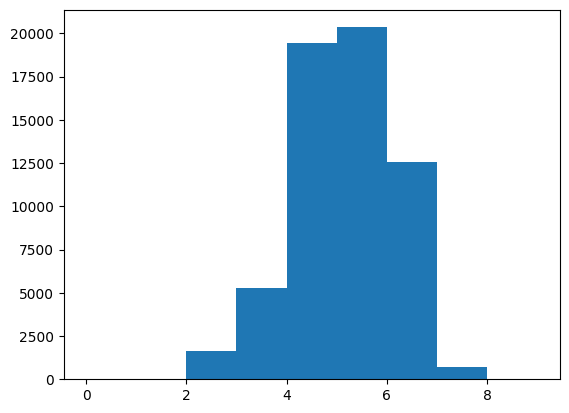

In [95]:
#plot Y distribution
plt.hist(Y, bins=range(10))[0].max()/N

In [202]:
def color_grayscale_arr(arr, background=True, pen=True, pad=0):
  '''
  Converts grayscale image changing the background and pen color and zoom.
  
    Args:
        arr: np.array
        background: bool
        pen: bool
        pad: int
    Returns:
        np.array
  '''
  assert arr.ndim == 2
  dtype = arr.dtype
  h, w = arr.shape
  arr = np.reshape(arr, [h, w, 1])
  if background: # green
    color = [0, 255, 0]
    if pen: # white
      arr = np.concatenate([arr,
                            255*np.ones((h, w, 1), dtype=dtype),
                            arr], axis=2)
    else: # black
      arr = np.concatenate([np.zeros((h, w, 1), dtype=dtype),
                            255*np.ones((h, w, 1), dtype=dtype)-arr,
                            np.zeros((h, w, 1), dtype=dtype)], axis=2)

  else: # red
    color = [255, 0, 0]
    if pen: # white
      arr = np.concatenate([255*np.ones((h, w, 1), dtype=dtype),
                            arr,
                            arr], axis=2)
    else: # black
      arr = np.concatenate([255*np.ones((h, w, 1), dtype=dtype)-arr,
                            np.zeros((h, w, 1), dtype=dtype),
                            np.zeros((h, w, 1), dtype=dtype)], axis=2)
  arr = np.pad(arr, ((pad, pad), (pad, pad), (0, 0)), 'constant', constant_values=0)
  arr[:pad, :, :] = color  
  arr[-pad:, :, :] = color
  arr[:, :pad, :] = color
  arr[:, -pad:, :] = color
  arr = Image.fromarray(arr.astype(np.uint8)).resize((28, 28))
  return np.array(arr)


In [210]:
N = 10000
k = 9

W = np.random.binomial(1, 0.8, N)
U = np.random.binomial(k, 0.8, N)
T = np.random.binomial(1, (W+U)/(k+1), N)
Y = np.round((9*(W/3 + U/(3*k) + T/3) + np.random.binomial(9, 0.5, N))/2).astype(int)

train_mnist = datasets.mnist.MNIST("./data", train=True, download=True)
images = train_mnist.data
labels = train_mnist.targets

dataset = []
for digit in range(10):
    idxs = np.where(Y==digit)[0]
    if len(idxs)==0: 
        continue
    images_digit = images[labels==digit]
    for i, idx in enumerate(idxs):
        x = images_digit[i]
        w = W[idx]
        u = U[idx]
        t = T[idx]
        y = Y[idx]
        x = color_grayscale_arr(np.array(x), background=w, pen=t, pad=4*u)

        dataset.append((Image.fromarray(x), (w, u, t, y)))



ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (10000, 2) + inhomogeneous part.

In [213]:
np.random.shuffle(dataset)
dataset

[(<PIL.Image.Image image mode=RGB size=28x28>, (1, 8, 1, 7)),
 (<PIL.Image.Image image mode=RGB size=28x28>, (1, 8, 1, 6)),
 (<PIL.Image.Image image mode=RGB size=28x28>, (1, 9, 1, 6)),
 (<PIL.Image.Image image mode=RGB size=28x28>, (1, 3, 0, 4)),
 (<PIL.Image.Image image mode=RGB size=28x28>, (1, 8, 1, 6)),
 (<PIL.Image.Image image mode=RGB size=28x28>, (1, 7, 1, 6)),
 (<PIL.Image.Image image mode=RGB size=28x28>, (1, 7, 1, 7)),
 (<PIL.Image.Image image mode=RGB size=28x28>, (1, 9, 1, 6)),
 (<PIL.Image.Image image mode=RGB size=28x28>, (0, 8, 1, 5)),
 (<PIL.Image.Image image mode=RGB size=28x28>, (1, 8, 1, 7)),
 (<PIL.Image.Image image mode=RGB size=28x28>, (1, 8, 1, 7)),
 (<PIL.Image.Image image mode=RGB size=28x28>, (1, 6, 0, 6)),
 (<PIL.Image.Image image mode=RGB size=28x28>, (1, 8, 1, 7)),
 (<PIL.Image.Image image mode=RGB size=28x28>, (1, 7, 0, 5)),
 (<PIL.Image.Image image mode=RGB size=28x28>, (1, 7, 1, 6)),
 (<PIL.Image.Image image mode=RGB size=28x28>, (1, 9, 1, 7)),
 (<PIL.I

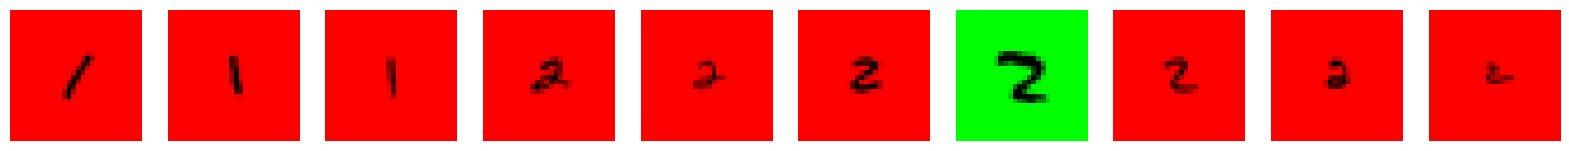

In [209]:
# print some examples
fig, axs = plt.subplots(1, 10, figsize=(20, 2))
for i in range(10):
    x, _ = dataset[i]
    axs[i].imshow(x)
    axs[i].axis('off')
plt.show()


E[Y|T=1]= 6.200818909129075
E[Y|T=0]= 4.413423349877546
AD= 1.7873955592515287


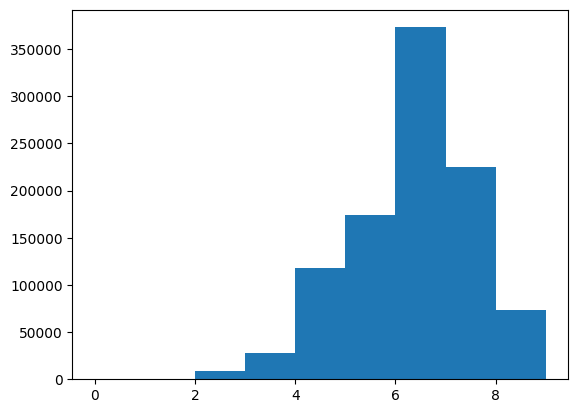

In [34]:
plt.hist(Y, bins=range(10));
print("E[Y|T=1]=", np.mean(Y[T==1]))
print("E[Y|T=0]=", np.mean(Y[T==0]))
print("AD=", np.mean(Y[T==1])-np.mean(Y[T==0]))